In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import string
import dotenv
import os

from mistralai import Mistral
import requests
import faiss

In [2]:
# Load the datasets
# Coded reports
df_reports = pd.read_csv("data/LLM-WERD Outputs_v2.csv")
# UN regions
# The UNSD file uses semicolons as delimiters
df_unsd = pd.read_csv("data/UNSD.csv", sep=";")

In [3]:
# Calculate the length (in words) of each reform_description
# We convert to string first to handle any potential missing values (NaNs)
df_reports["desc_word_count"] = df_reports["reform_description"].astype(str).apply(lambda x: len(x.split()))
df_reports["desc_word_count"].head()

0     1
1    25
2    32
3    41
4    16
Name: desc_word_count, dtype: int64

In [4]:
# Extract the organizational acronym from 'report_type'
# We split by '_' and grab the first element, handling missing values gracefully
df_reports["org_acronym"] = df_reports["report_type"].astype(str).apply(lambda x: x.split('_')[0])
df_reports["org_acronym"] = df_reports["org_acronym"].replace("nan", "Unknown")

In [5]:
# Standardize column names and strip trailing spaces for a clean merge
df_unsd = df_unsd.rename(columns={"Country or Area": "country", "Region Name": "region"})
df_reports["country"] = df_reports["country"].astype(str).str.strip()
df_unsd["country"] = df_unsd["country"].astype(str).str.strip()

# Map mismatched common country names to UNSD formal names
country_map = {
    "Democratic Republic of Congo": "Democratic Republic of the Congo",
    "Brunei": "Brunei Darussalam",
    "United Kingdom": "United Kingdom of Great Britain and Northern Ireland",
    "England": "United Kingdom of Great Britain and Northern Ireland",
    "USA": "United States of America",
    "Korea": "Republic of Korea",
    "Laos": "Lao People's Democratic Republic",
    "Turkey": "Türkiye",
    "Slovak Republic": "Slovakia",
    "Hong Kong": "China, Hong Kong Special Administrative Region",
    "Nigeria (Lagos State)": "Nigeria",
    "Northern Cyprus": "Cyprus",
    # Simplifying a few combined region strings for mapping:
    "Thailand (Hong Kong)": "Thailand",  
    "Thailand (Israel)": "Thailand",
    "Thailand (Australia)": "Thailand"
}
df_reports["country"] = df_reports["country"].replace(country_map)

# Merge datasets to assign a region to each report
df_merged = pd.merge(df_reports, df_unsd[["country", "region"]], on="country", how="left")

In [6]:
# Filter for the specific coders we want to compare
target_coders = ["Esther", "Liam", "claude-sonnet-4-6", "gemini-3.1-pro", "chatgpt-5.5"]
df_filtered = df_merged[df_merged["coder"].isin(target_coders)]

# Group by coder and calculate the average word count
avg_length_by_coder = df_filtered.groupby("coder")["desc_word_count"].mean().round(2).reset_index()

# Sort the results for better readability
avg_length_by_coder = avg_length_by_coder.sort_values(by="desc_word_count", ascending=False)

# Display the resulting comparison
print(avg_length_by_coder.to_string(index=False))

            coder  desc_word_count
           Esther            45.42
claude-sonnet-4-6            35.14
             Liam            27.15
      chatgpt-5.5            24.00
   gemini-3.1-pro            23.71


In [7]:
# Calculate overall average description length per report type (org acronym)
avg_by_org = df_filtered.groupby("org_acronym")["desc_word_count"].mean().round(2).reset_index()
avg_by_org = avg_by_org.sort_values(by="desc_word_count", ascending=False)

# 5. Calculate subdivided average description length by org and coder
avg_by_org_coder = df_filtered.groupby(["org_acronym", "coder"])["desc_word_count"].mean().round(2).reset_index()

# Pivot the table so that coders are columns and report types are rows
pivot_org_coder = avg_by_org_coder.pivot(index="org_acronym", columns="coder", values="desc_word_count")

print("--- Overall Average Length by Report Type (Organization) ---")
print(avg_by_org.to_string(index=False))
print("\n--- Average Length by Report Type and Coder ---")
print(pivot_org_coder.to_string())

--- Overall Average Length by Report Type (Organization) ---
     org_acronym  desc_word_count
      Technology            63.16
           WBPAD            50.24
           WBSAR            42.59
           SABER            35.01
            RNPE            34.80
          UNESCO            34.57
Non-state actors            33.86
             IEE            29.26
             EPO            28.67

--- Average Length by Report Type and Coder ---
coder             Esther   Liam  chatgpt-5.5  claude-sonnet-4-6  gemini-3.1-pro
org_acronym                                                                    
EPO                42.04  25.86        21.64              34.36           20.72
IEE                35.67    NaN        22.83              30.92           21.85
Non-state actors   46.85    NaN        24.61              37.36           20.12
RNPE               36.59    NaN        21.31              37.42           25.24
SABER              51.13  29.86        27.02              38.03       

Technology reports correspond to the longest report descriptions by coders, probably due to elaboration of specific metrics or provisions...

In [8]:
# Calculate overall average length by Region
avg_by_region = df_filtered.groupby("region")["desc_word_count"].mean().round(2).reset_index()
avg_by_region = avg_by_region.sort_values(by="desc_word_count", ascending=False)

# Calculate subdivided average length by Region and Coder
avg_by_region_coder = df_filtered.groupby(["region", "coder"])["desc_word_count"].mean().round(2).reset_index()
pivot_region_coder = avg_by_region_coder.pivot(index="region", columns="coder", values="desc_word_count")

print("--- Overall Average Length by Region ---")
print(avg_by_region.to_string(index=False))
print("\n--- Average Length by Region and Coder ---")
print(pivot_region_coder.to_string())

--- Overall Average Length by Region ---
  region  desc_word_count
 Oceania            67.45
  Africa            40.28
Americas            34.70
  Europe            33.91
    Asia            31.85

--- Average Length by Region and Coder ---
coder     Esther   Liam  chatgpt-5.5  claude-sonnet-4-6  gemini-3.1-pro
region                                                                 
Africa     46.76    NaN        23.98              37.42           22.65
Americas   52.73  33.35        21.43              31.98           28.00
Asia       40.80  25.64        24.09              34.39           24.19
Europe     42.30    NaN        25.35              35.51           21.68
Oceania   124.27    NaN        33.67              43.33           42.29


            Model  mean   std   min   max
      chatgpt-5.5 0.226 0.070 0.070 0.357
claude-sonnet-4-6 0.272 0.096 0.032 0.480
   gemini-3.1-pro 0.189 0.079 0.031 0.352


/var/folders/_9/mmm6nxpn0232mrs5lqsd9smw0000gn/T/ipykernel_22360/458424426.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=results_df, x="Model", y="Jaccard_Similarity", inner="quartile", palette="Set2")


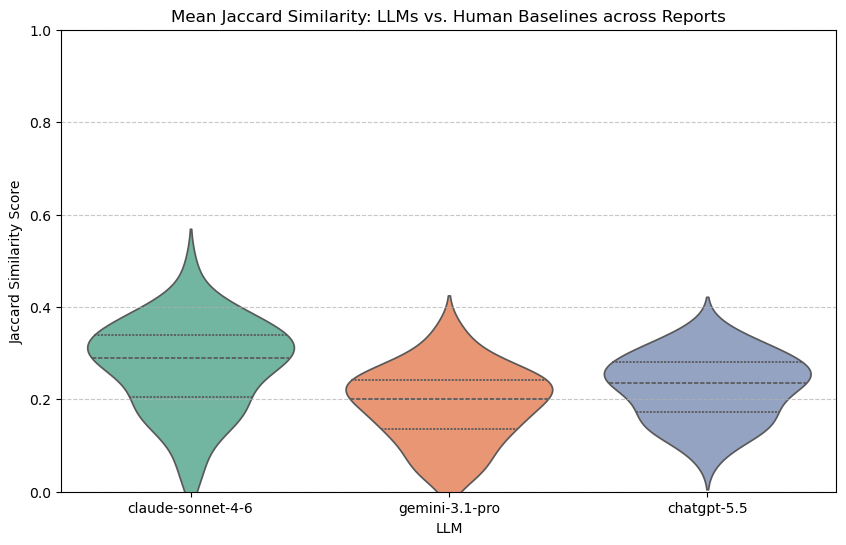

In [9]:
def tokenize(text):
    if pd.isna(text):
        return set()
    text = str(text).lower().translate(str.maketrans("", "", string.punctuation))
    return set(text.split())

def jaccard_sim(set1, set2):
    if not set1 and not set2:
        return 0.0
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union > 0 else 0.0

human_coders = ["Esther", "Liam"]
ai_coders = ["claude-sonnet-4-6", "gemini-3.1-pro", "chatgpt-5.5"]
results = []

# Group strictly by report id
grouped = df_filtered.dropna(subset=["report_type"]).groupby("report_type")

for name, group in grouped:
    # Build human ground truth set for the ENTIRE report
    human_texts = group[group["coder"].isin(human_coders)]["reform_description"].dropna().tolist()
    if not human_texts:
        continue 
        
    human_tokens = set()
    for text in human_texts:
        human_tokens.update(tokenize(text))
        
    if not human_tokens:
        continue
        
    # Compare each AI model to the human ground truth for the same report
    for ai_coder in ai_coders:
        ai_texts = group[group["coder"] == ai_coder]["reform_description"].dropna().tolist()
        if ai_texts:
            ai_tokens = set()
            for text in ai_texts:
                ai_tokens.update(tokenize(text))
            
            score = jaccard_sim(human_tokens, ai_tokens)
            results.append({"Model": ai_coder, "Jaccard_Similarity": score})

results_df = pd.DataFrame(results)

# Generate Violin Plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=results_df, x="Model", y="Jaccard_Similarity", inner="quartile", palette="Set2")
plt.title("Mean Jaccard Similarity: LLMs vs. Human Baselines across Reports")
plt.ylabel("Jaccard Similarity Score")
plt.xlabel("LLM")
plt.ylim(0, 1.0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.savefig("jaccard_similarity.png", bbox_inches="tight")

# Output Summary Stats
summary = results_df.groupby("Model")["Jaccard_Similarity"].describe().round(3).reset_index()
print(summary[["Model", "mean", "std", "min", "max"]].to_string(index=False))

In [10]:
dotenv.load_dotenv(dotenv_path="mistral.env")

MISTRAL_API_KEY = os.environ["MISTRAL_API_KEY"]

In [11]:
# Create a list to hold our concatenated text blocks
text_data = []

# Group strictly by report_type using the filtered dataframe
grouped = df_filtered.dropna(subset=["report_type"]).groupby("report_type")

for report_type, group in grouped:
    # 1. Build human ground truth text for the ENTIRE report
    human_texts = group[group["coder"].isin(["Esther", "Liam"])]["reform_description"].dropna().astype(str).tolist()
    human_combined = " ".join(human_texts)
    if len(human_combined.strip()) > 0:
        text_data.append({
            "report_type": report_type, 
            "coder_class": "Human Ground Truth", 
            "text": human_combined
        })
        
    # 2. Build text for each AI model for the ENTIRE report
    for ai_coder in ["claude-sonnet-4-6", "gemini-3.1-pro", "chatgpt-5.5"]:
        ai_texts = group[group["coder"] == ai_coder]["reform_description"].dropna().astype(str).tolist()
        ai_combined = " ".join(ai_texts)
        if len(ai_combined.strip()) > 0:
            text_data.append({
                "report_type": report_type, 
                "coder_class": ai_coder, 
                "text": ai_combined
            })

# Convert to a clean DataFrame
df_texts = pd.DataFrame(text_data)
print(f"Total text blocks prepared: {len(df_texts)}")

Total text blocks prepared: 192


In [12]:
df_texts.head()

,report_type,coder_class,text
0,EPO_Brazil,Human Ground Truth,Portugal’s Education Territories for Priority ...
1,EPO_Brazil,claude-sonnet-4-6,A national system for evaluating higher educat...
2,EPO_Brazil,gemini-3.1-pro,Updated pedagogical guidelines that act as a r...
3,EPO_Brazil,chatgpt-5.5,Education financing mechanism establishing red...
4,EPO_Norway,Human Ground Truth,Norway has introduced several revisions to its...


In [13]:
# Initialize the client with your loaded key
client = Mistral(api_key=MISTRAL_API_KEY)

def get_document_embedding(text, max_words=6000):
    """
    Chunks long texts, fetches embeddings for all chunks in one API call, 
    and returns the mean pooled document embedding.
    """
    words = text.split()
    if not words:
        return np.zeros(1024) # mistral-embed vectors are 1024 dimensions
        
    # Chunk the text based on the max_words threshold
    chunks = [" ".join(words[i:i + max_words]) for i in range(0, len(words), max_words)]
    
    try:
        # Pass all chunks for this document in a single API request
        response = client.embeddings.create(
            model="mistral-embed",
            inputs=chunks
        )
        
        # Extract the embeddings (list of arrays)
        chunk_embeddings = [np.array(data.embedding) for data in response.data]
        
        # Aggregate chunks into a single vector using mean pooling along the columns (axis=0)
        doc_embedding = np.mean(chunk_embeddings, axis=0)
        return doc_embedding
        
    except Exception as e:
        print(f"Error fetching embedding: {e}")
        return np.full(1024, np.nan)

print(f"Retrieving embeddings from Mistral for {len(df_texts)} text blocks...")

# Apply the function to get embeddings (this will take a moment to run)
df_texts["embedding"] = df_texts["text"].apply(get_document_embedding)

# Save the dataset immediately so we don't lose the API results
df_texts.to_pickle("data/mistral_embeddings.pkl")

print("Success! Embeddings retrieved and saved to 'data/mistral_embeddings.pkl'")

Retrieving embeddings from Mistral for 192 text blocks...
Error fetching embedding: API error occurred: Status 400. Body: {"object":"error","message":"Input id 0 has 8747 tokens, exceeding max 8192 tokens.","type":"invalid_request_prompt","param":null,"code":"3210","raw_status_code":400}
Error fetching embedding: API error occurred: Status 400. Body: {"object":"error","message":"Input id 0 has 8887 tokens, exceeding max 8192 tokens.","type":"invalid_request_prompt","param":null,"code":"3210","raw_status_code":400}
Success! Embeddings retrieved and saved to 'data/mistral_embeddings.pkl'


In [14]:
# Load the existing dataset with the missing vectors
df_texts = pd.read_pickle("data/mistral_embeddings.pkl")

# Helper function to check if a vector failed (is full of NaNs)
def is_failed_embedding(emb):
    if not isinstance(emb, np.ndarray):
        return True
    return np.isnan(emb).all()

# Find the rows that need to be re-run
failed_mask = df_texts["embedding"].apply(is_failed_embedding)
failed_rows = df_texts[failed_mask]

print(f"Found {len(failed_rows)} failed embeddings.")

Found 2 failed embeddings.


In [15]:
# Redefine our fetcher with a safer, smaller chunk size
def get_document_embedding_safe(text, max_words=4500):
    """Uses a safer 4500-word limit to guarantee it stays under 8192 tokens."""
    words = text.split()
    if not words:
        return np.zeros(1024)
        
    chunks = [" ".join(words[i:i + max_words]) for i in range(0, len(words), max_words)]
    
    try:
        response = client.embeddings.create(
            model="mistral-embed",
            inputs=chunks
        )
        chunk_embeddings = [np.array(data.embedding) for data in response.data]
        return np.mean(chunk_embeddings, axis=0)
    except Exception as e:
        print(f"Error on retry: {e}")
        return np.full(1024, np.nan)

# Re-run only the failed rows
if len(failed_rows) > 0:
    print("Retrying failed embeddings with smaller chunk sizes (4500 words)...")
    df_texts.loc[failed_mask, "embedding"] = df_texts.loc[failed_mask, "text"].apply(get_document_embedding_safe)

# Final Verification
final_failed = df_texts["embedding"].apply(is_failed_embedding).sum()
print(f"Remaining failures after retry: {final_failed}")

if final_failed == 0:
    # Overwrite the pickle file with the complete dataset
    df_texts.to_pickle("data/mistral_embeddings.pkl")
    print("Successfully recovered all embeddings and updated 'data/mistral_embeddings.pkl'!")
else:
    print("Some embeddings still failed. Check the error messages above.")

Retrying failed embeddings with smaller chunk sizes (4500 words)...
Remaining failures after retry: 0
Successfully recovered all embeddings and updated 'data/mistral_embeddings.pkl'!


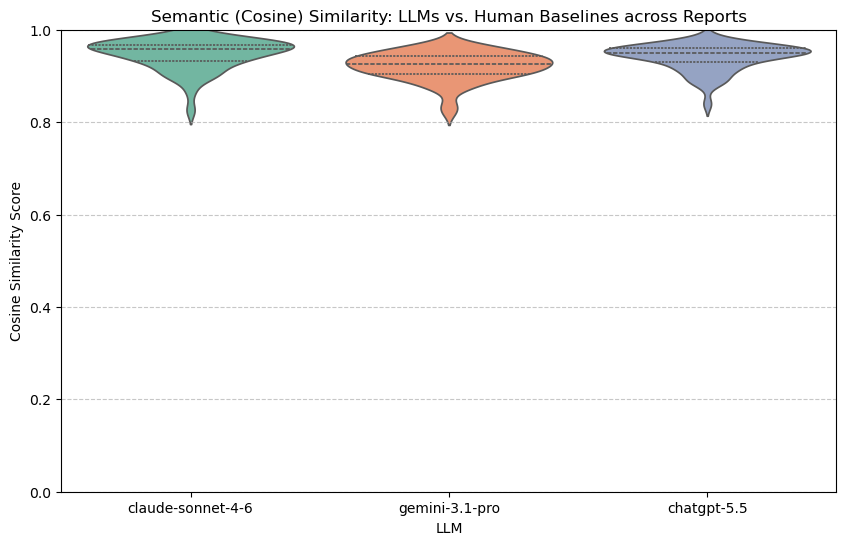

--- Cosine Similarity Summary ---
      coder_class  mean   std   min   max
      chatgpt-5.5 0.941 0.028 0.840 0.977
claude-sonnet-4-6 0.947 0.033 0.826 0.983
   gemini-3.1-pro 0.921 0.031 0.822 0.966


In [16]:
from scipy.spatial.distance import cosine

# Load the generated embeddings
df_texts = pd.read_pickle("data/mistral_embeddings.pkl")

# Separate Human Baseline from AI Models
human_df = df_texts[df_texts["coder_class"] == "Human Ground Truth"][["report_type", "embedding"]].rename(columns={"embedding": "human_embedding"})
ai_df = df_texts[df_texts["coder_class"] != "Human Ground Truth"]

# Merge them to align AI-Human pairs for the same report
merged_emb = pd.merge(ai_df, human_df, on="report_type", how="inner")

# Calculate Cosine Similarity
def calc_similarity(row):
    # scipy's cosine() function returns distance. Similarity is 1 - distance.
    if isinstance(row["embedding"], np.ndarray) and isinstance(row["human_embedding"], np.ndarray):
        return 1 - cosine(row["embedding"], row["human_embedding"])
    return np.nan

merged_emb["cosine_similarity"] = merged_emb.apply(calc_similarity, axis=1)

# Drop any potential NaNs just to be safe for visualization
merged_emb = merged_emb.dropna(subset=["cosine_similarity"])

# Generate Violin Plot
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=merged_emb, 
    x="coder_class", 
    y="cosine_similarity", 
    inner="quartile", 
    hue="coder_class",
    palette="Set2",
    legend=False
)
plt.title("Semantic (Cosine) Similarity: LLMs vs. Human Baselines across Reports")
plt.ylabel("Cosine Similarity Score")
plt.xlabel("LLM")
plt.ylim(0, 1.0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.savefig("cosine_similarity_violin.png", bbox_inches="tight")
plt.show()

# Output Summary Stats
summary_cos = merged_emb.groupby("coder_class")["cosine_similarity"].describe().round(3).reset_index()
print("--- Cosine Similarity Summary ---")
print(summary_cos[["coder_class", "mean", "std", "min", "max"]].to_string(index=False))

In [17]:
# Extract Organization Acronym
merged_emb["org_acronym"] = merged_emb["report_type"].astype(str).apply(lambda x: x.split('_')[0])

# Re-attach the country data from the original reports dataframe
df_reports_unique = df_filtered.dropna(subset=["report_type"])[["report_type", "country"]].drop_duplicates()
merged_emb = pd.merge(merged_emb, df_reports_unique, on="report_type", how="left")

# Apply the Country Mapping & Merge Region Data
merged_emb["country"] = merged_emb["country"].astype(str).str.strip()
merged_emb["country"] = merged_emb["country"].replace(country_map)  # Using the dict you defined earlier
merged_emb = pd.merge(merged_emb, df_unsd[["country", "region"]], on="country", how="left")

# Generate Pivot Table for Organization Acronyms
org_pivot = merged_emb.pivot_table(
    index="org_acronym", 
    columns="coder_class", 
    values="cosine_similarity", 
    aggfunc="mean"
).round(3)

print("--- Mean Semantic Similarity by Report Type (Organization) ---")
print(org_pivot.to_string())

# Generate Pivot Table for Regions
region_pivot = merged_emb.pivot_table(
    index="region", 
    columns="coder_class", 
    values="cosine_similarity", 
    aggfunc="mean"
).round(3)

print("\n--- Mean Semantic Similarity by Region ---")
print(region_pivot.to_string())

--- Mean Semantic Similarity by Report Type (Organization) ---
coder_class       chatgpt-5.5  claude-sonnet-4-6  gemini-3.1-pro
org_acronym                                                     
EPO                     0.917              0.937           0.904
IEE                     0.944              0.963           0.938
Non-state actors        0.950              0.966           0.908
RNPE                    0.964              0.977           0.933
SABER                   0.948              0.944           0.919
Technology              0.927              0.916           0.925
UNESCO                  0.968              0.962           0.944
WBPAD                   0.896              0.900           0.893
WBSAR                   0.933              0.928           0.907

--- Mean Semantic Similarity by Region ---
coder_class  chatgpt-5.5  claude-sonnet-4-6  gemini-3.1-pro
region                                                     
Africa             0.935              0.949           0.91

In [18]:
# Drop rows without a valid report_type or report_year
df_clean = df_reports.dropna(subset=['report_type', 'report_year']).copy()

# Extract the organizational acronym
df_clean['org_acronym'] = df_clean['report_type'].astype(str).apply(lambda x: x.split('_')[0])

# Filter to unique reports 
# (We do this so reports with 15 extracted reforms don't heavily skew the median year vs a report with 1 reform)
unique_reports = df_clean[['report_type', 'org_acronym', 'report_year']].drop_duplicates()

# Calculate chronological stats per organization
year_stats = unique_reports.groupby('org_acronym')['report_year'].agg(
    Min_Year='min',
    Max_Year='max',
    Median_Year='median',
    Report_Count='count'
).astype({'Min_Year': int, 'Max_Year': int, 'Median_Year': int})

# Sort chronologically by the earliest report
year_stats = year_stats.sort_values(by='Min_Year')

print("--- Publication Year Ranges by Organization ---")
print(year_stats.to_string())

--- Publication Year Ranges by Organization ---
                  Min_Year  Max_Year  Median_Year  Report_Count
org_acronym                                                    
WBSAR                 1970      1993         1976             9
IEE                   1994      1994         1994            11
WBPAD                 1997      2011         2003             4
UNESCO                2006      2006         2006             5
RNPE                  2008      2020         2016             3
SABER                 2012      2019         2015             8
EPO                   2014      2021         2020             5
Non-state actors      2021      2021         2021             1
Technology            2023      2023         2023             3


Type-token ratio analysis:

/var/folders/_9/mmm6nxpn0232mrs5lqsd9smw0000gn/T/ipykernel_22360/3886023904.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


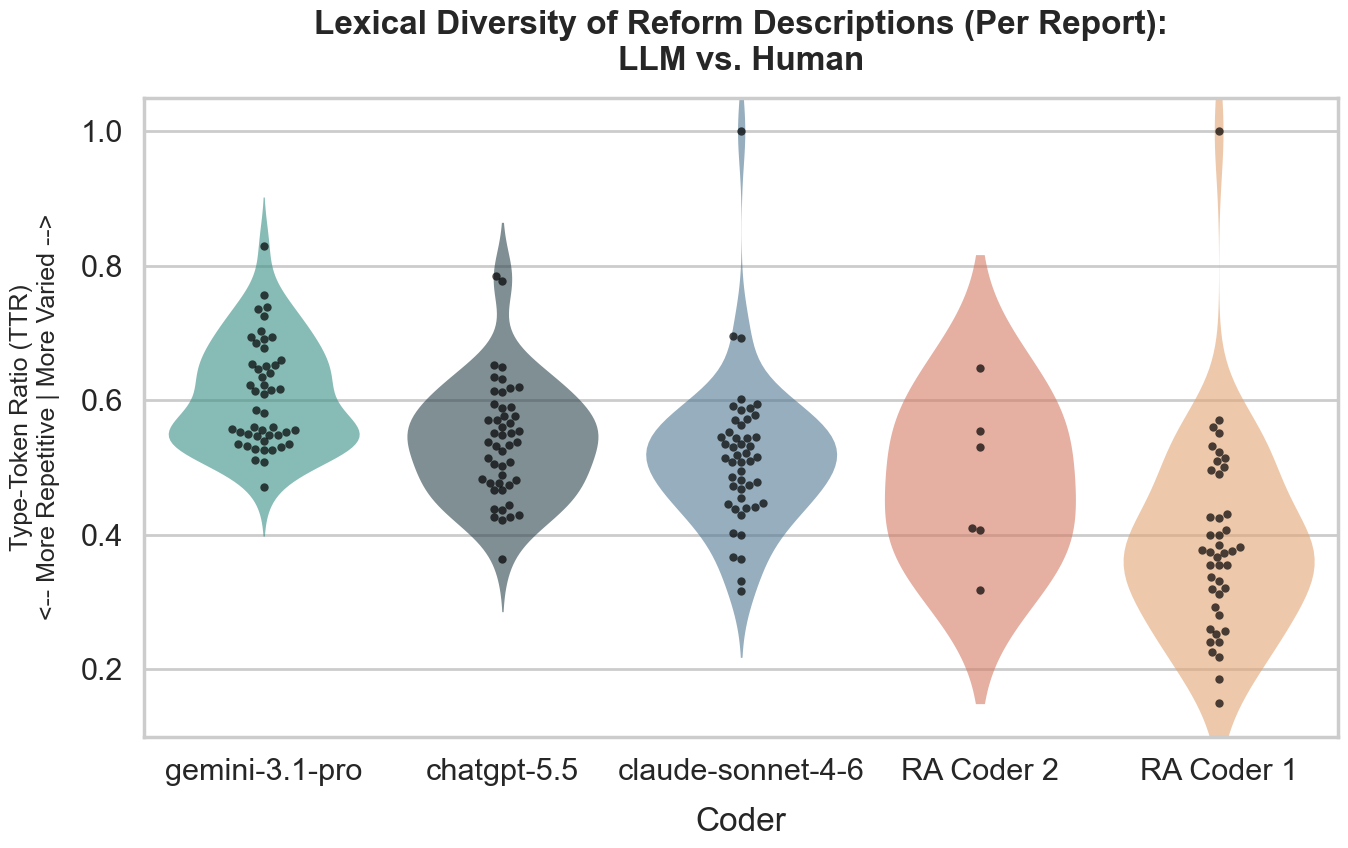

In [19]:
# Define the TTR calculation func
def get_ttr(text):
    if pd.isna(text): 
        return None
    text = str(text).lower().translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    word_count = len(tokens)
    return len(set(tokens)) / word_count if word_count > 0 else None

# Aggregate per report
# We group by report and coder, then join all descriptions into one text block
df_ttr_grouped = df_filtered.dropna(subset=["report_type", "reform_description"]).groupby(
    ["report_type", "coder"]
)["reform_description"].apply(lambda x: " ".join(x.astype(str))).reset_index()

# Calculate TTR on the aggregated report-level texts
df_ttr_grouped["ttr"] = df_ttr_grouped["reform_description"].apply(get_ttr)
df_ttr_grouped = df_ttr_grouped.dropna(subset=["ttr"])

# Anonymize the human coders
coder_mapping = {
    "Esther": "RA Coder 1",
    "Liam": "RA Coder 2"
}
df_ttr_grouped['coder_anon'] = df_ttr_grouped['coder'].replace(coder_mapping)

# Sort coders by mean TTR for a clean, descending visual
coder_order = df_ttr_grouped.groupby('coder_anon')['ttr'].mean().sort_values(ascending=False).index

# Configure for Conference Poster
sns.set_theme(style="whitegrid", context="poster") 
plt.figure(figsize=(14, 9))

palette = {
    "gemini-3.1-pro": "#2A9D8F", 
    "chatgpt-5.5": "#264653", 
    "claude-sonnet-4-6": "#457B9D", 
    "RA Coder 2": "#E76F51", 
    "RA Coder 1": "#F4A261"
}

# Build the Plot (Violin + Swarm)
sns.violinplot(
    data=df_ttr_grouped, 
    x="coder_anon", 
    y="ttr", 
    order=coder_order,
    palette=palette,
    inner=None, 
    alpha=0.6,
    linewidth=0
)

sns.swarmplot(
    data=df_ttr_grouped, 
    x="coder_anon", 
    y="ttr", 
    order=coder_order,
    color="black",
    alpha=0.7,
    size=6
)

# Format Labels and Axes
plt.title("Lexical Diversity of Reform Descriptions (Per Report):\nLLM vs. Human", pad=20, fontweight='bold')
plt.ylabel("Type-Token Ratio (TTR)\n<-- More Repetitive | More Varied -->", labelpad=15, fontsize=18)
plt.xlabel("Coder", labelpad=15)

# Adjust y-axis since aggregated texts will naturally have lower TTRs
plt.ylim(0.1, 1.05)

# 7. Save and Show
plt.tight_layout()
plt.savefig("poster_ttr_comparison_per_report.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from scipy.spatial.distance import jensenshannon

In [21]:
# Aggregate by report and coder
df_topic = df_filtered.dropna(subset=["report_type", "reform_description"]).groupby(
    ["report_type", "coder"]
)["reform_description"].apply(lambda x: " ".join(x.astype(str))).reset_index()

# Merge humans into a single baseline
coder_mapping = {"Esther": "Human Baseline", "Liam": "Human Baseline"}
df_topic["coder_class"] = df_topic["coder"].replace(coder_mapping)
df_corpus = df_topic.groupby(["report_type", "coder_class"])["reform_description"].apply(lambda x: " ".join(x)).reset_index()

# Extract Features (TF-IDF)
n_topics = 10
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words="english")
tfidf = tfidf_vectorizer.fit_transform(df_corpus["reform_description"])

# Fit NMF
nmf_model = NMF(n_components=n_topics, random_state=42, init="nndsvda")
nmf_weights = nmf_model.fit_transform(tfidf)

# Normalize weights so they sum to 1.0
nmf_distributions = nmf_weights / (nmf_weights.sum(axis=1, keepdims=True) + 1e-10)
df_corpus["topic_dist"] = list(np.nan_to_num(nmf_distributions))

# Generate Topic Labels (Top 3 Words)
feature_names = tfidf_vectorizer.get_feature_names_out()
topic_labels = [f"T{i+1}: {', '.join([feature_names[w] for w in topic.argsort()[:-4:-1]])}" 
                for i, topic in enumerate(nmf_model.components_)]

# Calculate Jensen-Shannon Distance (0 to 1)
results = []
for report, group in df_corpus.groupby("report_type"):
    human_row = group[group["coder_class"] == "Human Baseline"]
    if human_row.empty: continue
    
    human_dist = human_row.iloc[0]["topic_dist"]
    for _, ai_row in group[group["coder_class"] != "Human Baseline"].iterrows():
        jsd = jensenshannon(human_dist, ai_row["topic_dist"])
        results.append({"report_type": report, "coder_class": ai_row["coder_class"], "js_distance": jsd})

df_jsd = pd.DataFrame(results)

print("--- Mean Topical Divergence (Jensen-Shannon Distance) ---")
print("*(Closer to 0 is better)*")
print(df_jsd.groupby('coder_class')['js_distance'].mean().sort_values().round(3).to_string())

# Find edge cases
report_divergence = df_jsd.groupby('report_type')['js_distance'].mean().sort_values()
least_divergent_report = report_divergence.index[0]
most_divergent_report = report_divergence.index[-1]

print(f"\nHighly Aligned (Consensus): {least_divergent_report}")
print(f"Highly Divergent (Conflict): {most_divergent_report}")

--- Mean Topical Divergence (Jensen-Shannon Distance) ---
*(Closer to 0 is better)*
coder_class
claude-sonnet-4-6    0.224
chatgpt-5.5          0.235
gemini-3.1-pro       0.303

Highly Aligned (Consensus): IEE_Ethiopia
Highly Divergent (Conflict): WBSAR_Haiti


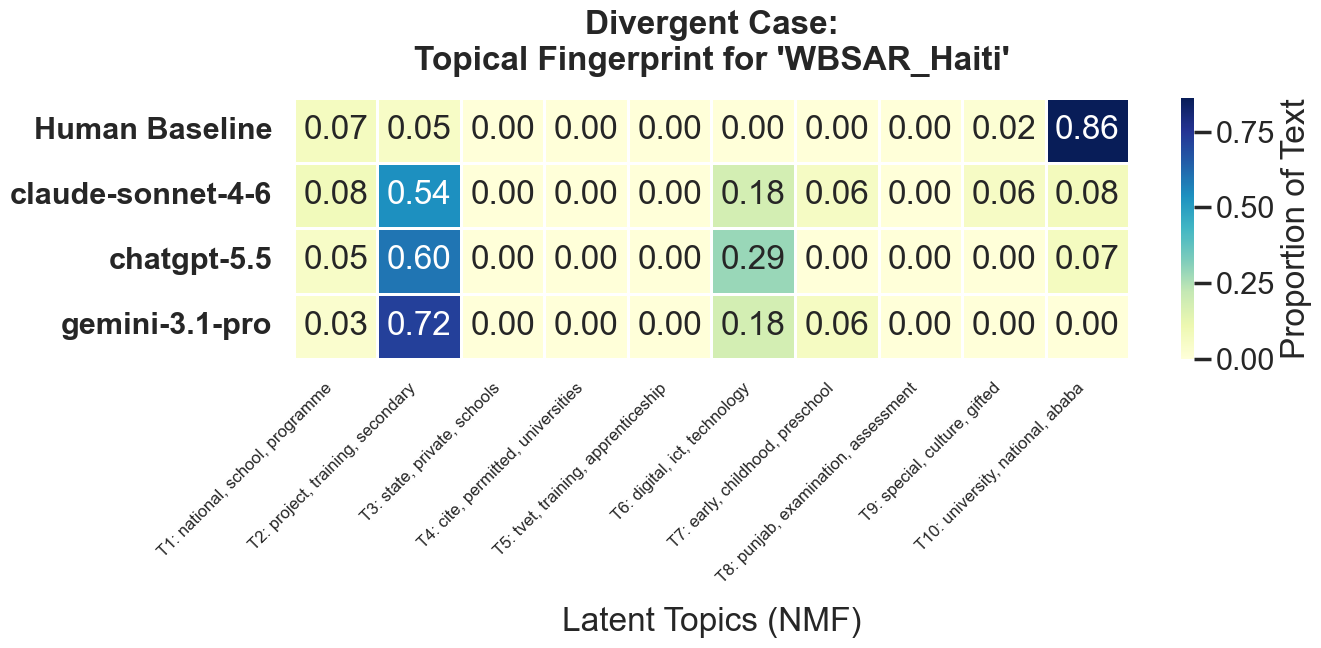

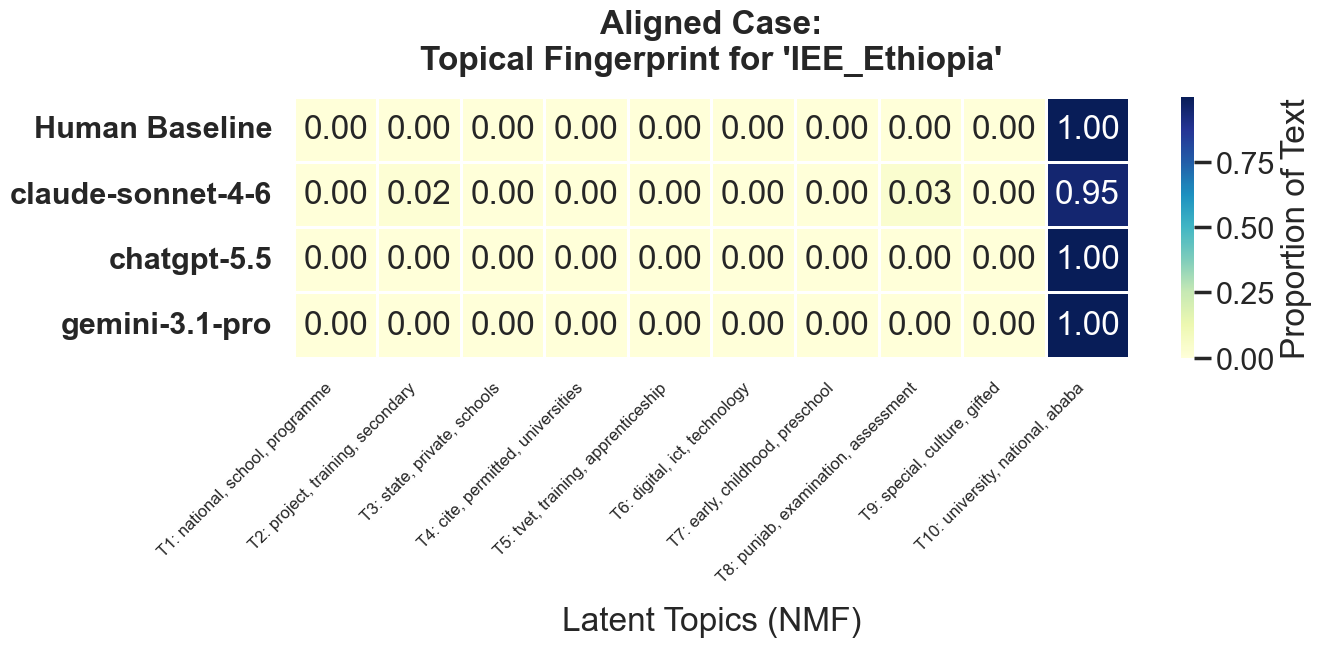

In [22]:
# 5. Visualizing the Fingerprints
def plot_topical_fingerprint(report_name, title_prefix, filename):
    report_data = df_corpus[df_corpus["report_type"] == report_name].copy()
    
    # Build dataframe for heatmap
    dist_matrix = np.vstack(report_data["topic_dist"].values)
    df_heatmap = pd.DataFrame(dist_matrix, index=report_data["coder_class"], columns=topic_labels)
    
    # Reorder to keep baseline at the top
    order = ["Human Baseline", "claude-sonnet-4-6", "chatgpt-5.5", "gemini-3.1-pro"]
    existing_coders = [c for c in order if c in df_heatmap.index]
    df_heatmap = df_heatmap.loc[existing_coders]
    
    sns.set_theme(style="white", context="poster")
    plt.figure(figsize=(14, 7))
    
    sns.heatmap(
        df_heatmap, cmap="YlGnBu", annot=True, fmt=".2f", 
        cbar_kws={"label": "Proportion of Text"}, linewidths=1, linecolor='white'
    )
    
    plt.title(f"{title_prefix}\nTopical Fingerprint for '{report_name}'", pad=20, fontweight='bold')
    plt.ylabel("")
    plt.xlabel("Latent Topics (NMF)", labelpad=15)
    
    plt.xticks(rotation=45, ha="right", fontsize=12)
    plt.yticks(rotation=0, fontweight="bold")
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

# Generate visual for the most divergent report (The COT failure)
plot_topical_fingerprint(most_divergent_report, "Divergent Case:", f"divergent_{most_divergent_report}.png")

# Generate visual for the most aligned report (The Consensus success)
plot_topical_fingerprint(least_divergent_report, "Aligned Case:", f"aligned_{least_divergent_report}.png")

/Users/jball/anaconda3/envs/werd/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 10.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/jball/anaconda3/envs/werd/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 18.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/jball/anaconda3/envs/werd/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 29.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


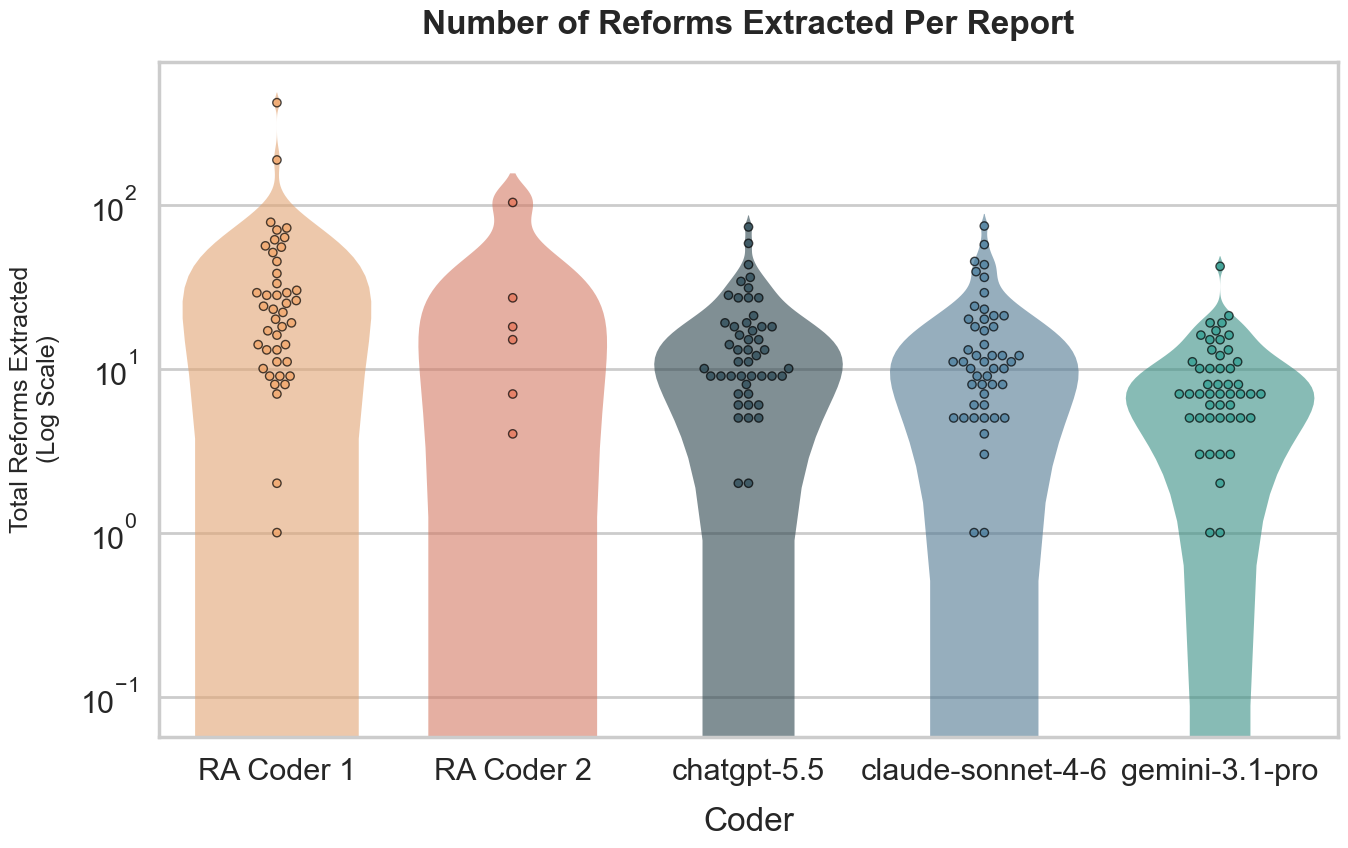

In [23]:
df_counts = df_filtered.dropna(subset=["reform_description", "report_type"]).copy()
reform_counts = df_counts.groupby(["report_type", "coder"]).size().reset_index(name="reform_count")

# Anonymize the Human Coders (Catching both standard names and previously merged names)
coder_mapping = {
    "Esther": "RA Coder 1",
    "Liam": "RA Coder 2",
    "Human Baseline": "Human Baseline" # In case they are already merged
}
reform_counts["coder_anon"] = reform_counts["coder"].replace(coder_mapping)

# Sort coders by mean count for a clean, descending visual
coder_order = reform_counts.groupby("coder_anon")["reform_count"].mean().sort_values(ascending=False).index

# Configure for Conference Poster
sns.set_theme(style="whitegrid", context="poster") 
plt.figure(figsize=(14, 9))

# Added "Human Baseline" to the palette to fix the ValueError
palette = {
    "gemini-3.1-pro": "#2A9D8F", 
    "chatgpt-5.5": "#264653", 
    "claude-sonnet-4-6": "#457B9D", 
    "RA Coder 2": "#E76F51", 
    "RA Coder 1": "#F4A261",
    "Human Baseline": "#F4A261" 
}

# 4. Build the Plot (Violin + Swarm)
# Added hue="coder_anon" and legend=False to comply with latest Seaborn updates
sns.violinplot(
    data=reform_counts, 
    x="coder_anon", 
    y="reform_count", 
    order=coder_order,
    hue="coder_anon",
    palette=palette,
    inner=None, 
    alpha=0.6,
    linewidth=0,
    legend=False
)

sns.swarmplot(
    data=reform_counts, 
    x="coder_anon", 
    y="reform_count", 
    order=coder_order,
    hue="coder_anon",
    palette=palette,
    alpha=0.7,
    size=6,
    legend=False,
    edgecolor="black",
    linewidth=1
)

# 5. Format Labels and Axes
plt.title("Number of Reforms Extracted Per Report", pad=20, fontweight='bold')
plt.ylabel("Total Reforms Extracted\n(Log Scale)", labelpad=15, fontsize=18)
plt.xlabel("Coder", labelpad=15)

# Set Y-axis to logarithmic to gracefully handle the massive human outliers 
plt.yscale("log")

# 6. Save and Show
plt.tight_layout()
plt.savefig("poster_reform_counts_anonymized.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
# Calculate Summary Statistics
table_summary = reform_counts.groupby('coder_anon')['reform_count'].agg(
    Total_Reforms_Extracted='sum',
    Mean_per_Report='mean',
    Median_per_Report='median',
    Min_Extracted='min',
    Max_Extracted='max'
).round(1)

# Sort by Mean descending
table_summary = table_summary.sort_values(by='Mean_per_Report', ascending=False)

# Rename the index for display
table_summary.index.name = "Coder / Model"

print("--- Volume of Extraction Summary ---")
print(table_summary.to_markdown())

--- Volume of Extraction Summary ---
| Coder / Model     |   Total_Reforms_Extracted |   Mean_per_Report |   Median_per_Report |   Min_Extracted |   Max_Extracted |
|:------------------|--------------------------:|------------------:|--------------------:|----------------:|----------------:|
| RA Coder 1        |                      1720 |              40   |                23   |               1 |             418 |
| RA Coder 2        |                       174 |              29   |                16.5 |               4 |             103 |
| chatgpt-5.5       |                       798 |              16.6 |                12.5 |               2 |              73 |
| claude-sonnet-4-6 |                       762 |              15.9 |                11   |               1 |              74 |
| gemini-3.1-pro    |                       444 |               9.2 |                 7   |               1 |              42 |
